In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, precision_score, recall_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Загрузка данных
df = pd.read_csv('/content/dispensarization_data_2026.csv')

# Целевая переменная
X = df.drop(columns=['Доклинический_риск'])
y = df['Доклинический_риск']

# Разделение
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Пайплайн предобработки
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[('num', numeric_transformer, numeric_features)]
)

Установка библиотек...
Все библиотеки установлены!

ЗАГРУЗКА ДАННЫХ
Пожалуйста, загрузите файл dispensarization_data_2026.csv


Saving dispensarization_data_2026.csv to dispensarization_data_2026 (2).csv
✅ Файл dispensarization_data_2026 (2).csv загружен. Размер: (1000, 18)

АНАЛИЗ ДАННЫХ
Размер данных: (1000, 18)

Колонки: ['Возраст', 'Пол_мужской', 'ИМТ', 'Окружность_талии_см', 'САД_мм_рт_ст', 'ДАД_мм_рт_ст', 'Пульсовое_давление', 'Глюкоза_натощак_ммоль_л', 'HbA1c_%', 'ЛПНП_ммоль_л', 'ЛПВП_ммоль_л', 'Триглицериды_ммоль_л', 'СКФ_мл_мин', 'Курение', 'Физическая_активность_мин_нед', 'ССЗ_риск_высокий', 'Статус_глюкозы', 'Доклинический_риск']

Типы данных:
Возраст                            int64
Пол_мужской                        int64
ИМТ                              float64
Окружность_талии_см              float64
САД_мм_рт_ст                     float64
ДАД_мм_рт_ст                     float64
Пульсовое_давление               float64
Глюкоза_натощак_ммоль_л          float64
HbA1c_%                          float64
ЛПНП_ммоль_л                     float64
ЛПВП_ммоль_л                     float64
Триглицериды_м

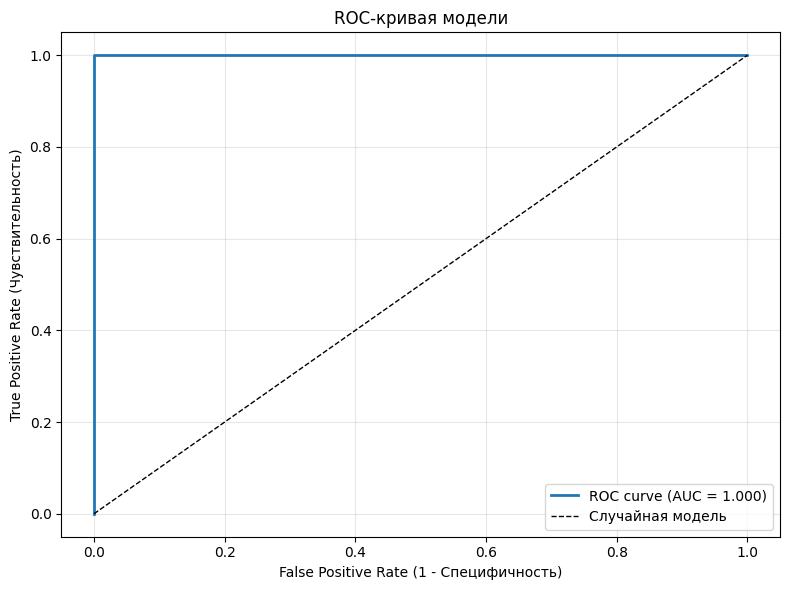

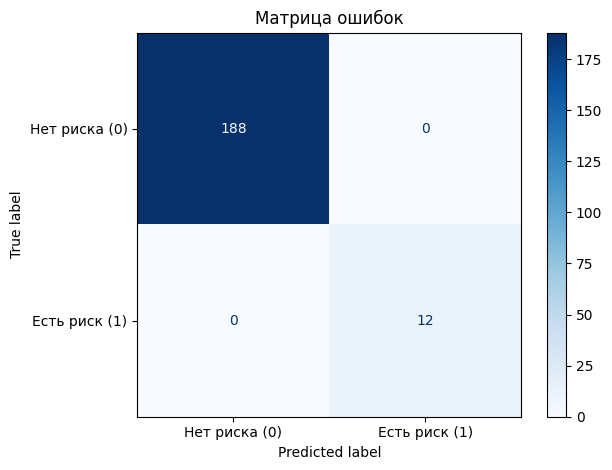

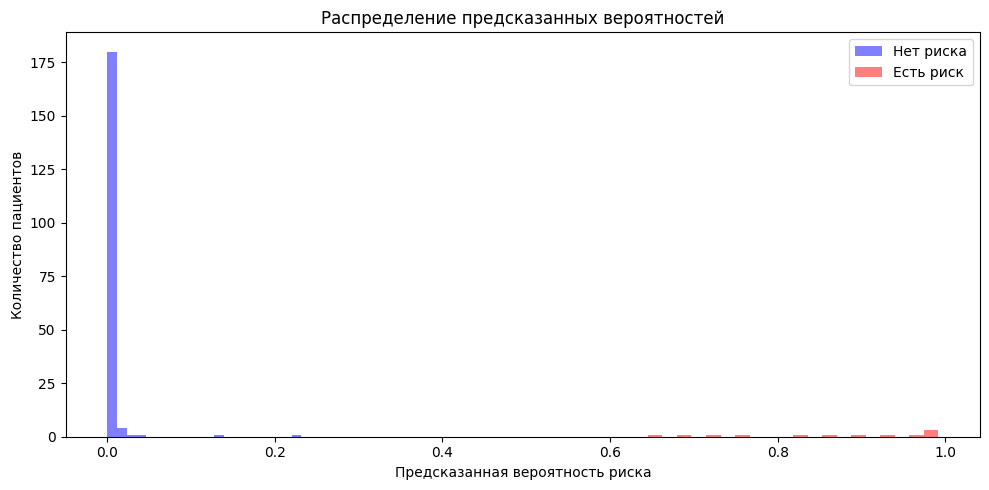

In [9]:

# ПРОГНОЗИРОВАНИЕ ДОКЛИНИЧЕСКОГО РИСКА

# ШАГ 1: Установка всех необходимых библиотек
print("Установка библиотек...")
!pip install flaml -q
!pip install lightgbm -q
!pip install xgboost -q
!pip install scikit-learn -q
!pip install pandas -q
!pip install numpy -q
!pip install matplotlib -q
!pip install joblib -q

print("Все библиотеки установлены!")

# ШАГ 2: Импорт библиотек
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_score, recall_score, classification_report
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from flaml import AutoML
import warnings
warnings.filterwarnings('ignore')

# ШАГ 3: ЗАГРУЗКА ДАННЫХ
print("\n" + "="*50)
print("ЗАГРУЗКА ДАННЫХ")
print("="*50)

from google.colab import files

print("Пожалуйста, загрузите файл dispensarization_data_2026.csv")
uploaded = files.upload()

# Загружаем данные
import io
for filename in uploaded.keys():
    df = pd.read_csv(io.BytesIO(uploaded[filename]))
    print(f"✅ Файл {filename} загружен. Размер: {df.shape}")

# ШАГ 4: АНАЛИЗ ДАННЫХ
print("\n" + "="*50)
print("АНАЛИЗ ДАННЫХ")
print("="*50)
print(f"Размер данных: {df.shape}")
print(f"\nКолонки: {df.columns.tolist()}")
print(f"\nТипы данных:\n{df.dtypes}")
print(f"\nЦелевая переменная 'Доклинический_риск':")
print(df['Доклинический_риск'].value_counts())
print(f"\nПроцент риска: {df['Доклинический_риск'].mean()*100:.2f}%")

# Проверка на пропуски
print(f"\nПропуски в данных: {df.isnull().sum().sum()}")
if df.isnull().sum().sum() > 0:
    print("Колонки с пропусками:")
    print(df.isnull().sum()[df.isnull().sum() > 0])

# ШАГ 5: РАЗДЕЛЕНИЕ ПРИЗНАКОВ И ЦЕЛИ
X = df.drop('Доклинический_риск', axis=1)
y = df['Доклинический_риск']

# ШАГ 6: РАЗБИЕНИЕ НА ОБУЧАЮЩУЮ И ТЕСТОВУЮ ВЫБОРКИ
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% на тест
    random_state=42,    # Для воспроизводимости
    stratify=y          # Сохраняем пропорцию классов
)

print(f"\nРазмер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Доля риска в обучении: {y_train.mean()*100:.2f}%")
print(f"Доля риска в тесте: {y_test.mean()*100:.2f}%")

# ШАГ 7: ПРЕДОБРАБОТКА ДАННЫХ
print("\n" + "="*50)
print("ПРЕДОБРАБОТКА ДАННЫХ")
print("="*50)

# Создаем пайплайн предобработки
numeric_cols = X.select_dtypes(include=[np.number]).columns

preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Заполняем пропуски медианой
    ('scaler', StandardScaler())                    # Нормализуем
])

# Применяем предобработку
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Преобразуем обратно в DataFrame для совместимости с FLAML
X_train_processed = pd.DataFrame(X_train_processed, columns=numeric_cols)
X_test_processed = pd.DataFrame(X_test_processed, columns=numeric_cols)

print("✅ Предобработка завершена")

# ШАГ 8: AutoML С FLAML (без catboost)
print("\n" + "="*50)
print("ОБУЧЕНИЕ AutoML МОДЕЛИ (FLAML)")
print("="*50)

# Настройка AutoML - используем только модели, которые точно есть
automl = AutoML()

# Обучение - убираем catboost из списка
print("Начинается автоматический поиск лучшей модели...")
print("Пробуем модели: Random Forest, LightGBM, XGBoost")
print("Это займет около 3-5 минут...")

try:
    automl.fit(
        X_train_processed, y_train,
        task='classification',           # Задача классификации
        time_budget=240,                 # 4 минуты на поиск
        metric='roc_auc',               # Оптимизируем ROC-AUC
        estimator_list=['rf', 'lgbm', 'xgboost'],  # Только доступные модели
        log_file_name='flaml_log.txt',
        verbose=3                        # Показываем процесс
    )
    print("✅ Обучение завершено успешно!")
except Exception as e:
    print(f"Ошибка при обучении: {e}")
    # Альтернативный вариант с только Random Forest
    print("\nПробуем альтернативный вариант с Random Forest...")
    automl.fit(
        X_train_processed, y_train,
        task='classification',
        time_budget=180,
        metric='roc_auc',
        estimator_list=['rf'],  # Только Random Forest
        verbose=3
    )

# ШАГ 9: ПРЕДСКАЗАНИЯ НА ТЕСТОВОЙ ВЫБОРКЕ
print("\n" + "="*50)
print("ПРЕДСКАЗАНИЕ И ОЦЕНКА")
print("="*50)

y_pred = automl.predict(X_test_processed)
y_proba = automl.predict_proba(X_test_processed)[:, 1]  # Вероятности для класса 1

# ШАГ 10: МЕТРИКИ КАЧЕСТВА
print("\nМЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ:")
print("-" * 40)
print(f"ROC-AUC:    {roc_auc_score(y_test, y_proba):.4f}")
print(f"Accuracy:   {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision:  {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall:     {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:   {f1_score(y_test, y_pred):.4f}")

print("\nПОДРОБНЫЙ ОТЧЕТ ПО КЛАССАМ:")
print(classification_report(y_test, y_pred, target_names=['Нет риска', 'Есть риск']))

# ШАГ 11: ИНФОРМАЦИЯ О ЛУЧШЕЙ МОДЕЛИ
print("\n" + "="*50)
print("ИНФОРМАЦИЯ О МОДЕЛИ")
print("="*50)
print(f"Лучшая модель: {automl.best_estimator}")
print(f"\nЛучшие гиперпараметры: {automl.best_config}")

# ШАГ 12: АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ ДЛЯ RANDOM FOREST
print("\n" + "="*50)
print("ВАЖНОСТЬ ПРИЗНАКОВ")
print("="*50)

# Пытаемся получить важность признаков для Random Forest
try:
    if 'rf' in str(automl.best_estimator).lower():
        importances = automl.model.estimator.feature_importances_
        feature_importance_df = pd.DataFrame({
            'Признак': numeric_cols,
            'Важность': importances
        }).sort_values('Важность', ascending=False)

        print("\nТоп-15 самых важных признаков:")
        print(feature_importance_df.head(15).to_string(index=False))

        # Визуализация важности признаков
        import matplotlib.pyplot as plt
        plt.figure(figsize=(10, 8))
        top_features = feature_importance_df.head(15)
        plt.barh(top_features['Признак'], top_features['Важность'])
        plt.xlabel('Важность')
        plt.title('Топ-15 важных признаков для предсказания риска')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
    else:
        print("Feature importance доступна только для Random Forest")
        print(f"Использованная модель: {automl.best_estimator}")
except Exception as e:
    print(f"Не удалось получить важность признаков: {e}")

# ШАГ 13: ПРИМЕР ПРЕДСКАЗАНИЯ ДЛЯ НОВЫХ ПАЦИЕНТОВ
print("\n" + "="*50)
print("ПРИМЕР ПРЕДСКАЗАНИЯ ДЛЯ НОВЫХ ДАННЫХ")
print("="*50)

# Создаем тестового пациента (средние значения)
sample_patient = pd.DataFrame([X_train_processed.mean()], columns=numeric_cols)
pred_proba = automl.predict_proba(sample_patient)[0, 1]
pred_label = automl.predict(sample_patient)[0]

print(f"Средние показатели пациента:")
for col in numeric_cols[:5]:  # Показываем первые 5 признаков
    print(f"  {col}: {sample_patient[col].values[0]:.2f}")
print(f"\nПредсказанный риск: {'ЕСТЬ' if pred_label == 1 else 'НЕТ'}")
print(f"Вероятность риска: {pred_proba:.3f} ({pred_proba*100:.1f}%)")

# ШАГ 14: ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
print("\n" + "="*50)
print("ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("="*50)

try:
    import matplotlib.pyplot as plt
    from sklearn.metrics import roc_curve, confusion_matrix, ConfusionMatrixDisplay

    # ROC-кривая
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, linewidth=2, label=f'ROC curve (AUC = {roc_auc_score(y_test, y_proba):.3f})')
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Случайная модель')
    plt.xlabel('False Positive Rate (1 - Специфичность)')
    plt.ylabel('True Positive Rate (Чувствительность)')
    plt.title('ROC-кривая модели')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Матрица ошибок
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Нет риска (0)', 'Есть риск (1)'])
    disp.plot(cmap='Blues')
    plt.title('Матрица ошибок')
    plt.tight_layout()
    plt.show()

    # Дополнительная визуализация: распределение вероятностей
    plt.figure(figsize=(10, 5))
    plt.hist(y_proba[y_test == 0], bins=20, alpha=0.5, label='Нет риска', color='blue')
    plt.hist(y_proba[y_test == 1], bins=20, alpha=0.5, label='Есть риск', color='red')
    plt.xlabel('Предсказанная вероятность риска')
    plt.ylabel('Количество пациентов')
    plt.title('Распределение предсказанных вероятностей')
    plt.legend()
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Ошибка визуализации: {e}")

